# Fraud Detection: From Transactions to Prioritized Alerts

## 1. Business Problem

**Decision:** identify suspicious transactions and choose an alert threshold that balances fraud recall with analyst workload.

**tl;dr:** This notebook engineers leakage-safe historical features in SQL, preserves chronology with a temporal split, compares an interpretable Logistic Regression baseline with HistGradientBoosting, and selects one capacity-aware demonstration threshold. All data are synthetic.

In [1]:
from pathlib import Path
import json, sqlite3, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / "data" / "sample"
ASSET_DIR = PROJECT_ROOT / "assets"
ASSET_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "font.size": 10, "axes.titlesize": 13,
    "axes.labelsize": 10, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.20,
})
BLUE, ORANGE, CHARCOAL = "#2463A6", "#D97706", "#273142"

## 2. Synthetic Dataset & Validation

The generator uses a fixed seed. Fraud labels are sampled from noisy combinations of amount, geography, device, timing, channel, velocity, and unobserved customer variation—never from a direct `is_suspicious` flag.

In [2]:
customers = pd.read_csv(DATA_DIR / "customers.csv")
transactions = pd.read_csv(DATA_DIR / "transactions.csv", parse_dates=["transaction_timestamp"])

checks = {
    "unique_customer_ids": customers.customer_id.is_unique,
    "unique_transaction_ids": transactions.transaction_id.is_unique,
    "all_customers_exist": transactions.customer_id.isin(customers.customer_id).all(),
    "non_negative_amounts": transactions.amount.ge(0).all(),
    "no_future_transactions": transactions.transaction_timestamp.max() < pd.Timestamp.now(),
    "binary_labels": set(transactions.is_fraud.unique()).issubset({0, 1}),
    "no_direct_leakage_column": not {"is_suspicious", "fraud_probability", "risk_score"}.intersection(transactions.columns),
}
assert all(checks.values())
dataset_summary = pd.Series({
    "customers": len(customers), "transactions": len(transactions),
    "start": transactions.transaction_timestamp.min(), "end": transactions.transaction_timestamp.max(),
    "fraud_cases": int(transactions.is_fraud.sum()), "fraud_rate": transactions.is_fraud.mean(),
})
display(pd.Series(checks, name="passed").to_frame())
display(dataset_summary.to_frame("value"))

,passed
unique_customer_ids,True
unique_transaction_ids,True
all_customers_exist,True
non_negative_amounts,True
no_future_transactions,True
binary_labels,True
no_direct_leakage_column,True


,value
customers,10000
transactions,100000
start,2025-01-01 00:05:37
end,2025-12-31 23:58:51
fraud_cases,584
fraud_rate,0.00584


## 3. Fraud Class Distribution

Accuracy is misleading for rare fraud: an all-legitimate classifier would look accurate while catching nothing. Precision, recall, F1, ROC-AUC, and especially **PR-AUC** are more informative.

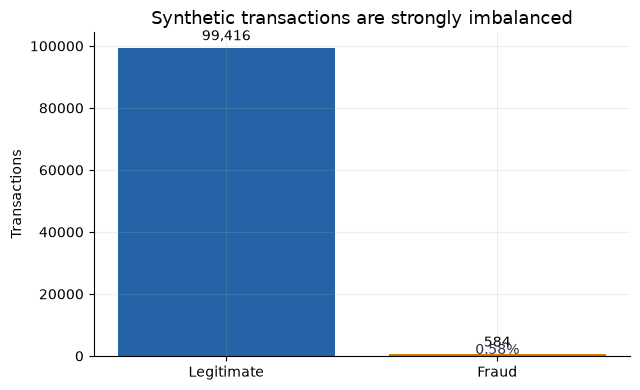

In [3]:
class_counts = transactions.is_fraud.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(["Legitimate", "Fraud"], class_counts.values, color=[BLUE, ORANGE])
ax.set(title="Synthetic transactions are strongly imbalanced", ylabel="Transactions")
ax.bar_label(bars, labels=[f"{v:,}" for v in class_counts.values], padding=3)
ax.text(1, class_counts.loc[1] * 1.10, f"{transactions.is_fraud.mean():.2%}", ha="center", color=CHARCOAL)
fig.tight_layout()
fig.savefig(ASSET_DIR / "fraud_class_imbalance.png", dpi=160)
plt.show()

## 4. SQL Feature Engineering

SQLite executes `sql/fraud_features.sql`. Historical windows end at `1 PRECEDING`, so the current label and all future transactions are excluded from customer features.

In [4]:
with sqlite3.connect(":memory:") as connection:
    customers.to_sql("customers", connection, index=False)
    transactions.assign(transaction_timestamp=transactions.transaction_timestamp.dt.strftime("%Y-%m-%d %H:%M:%S")).to_sql(
        "transactions", connection, index=False
    )
    sql = (PROJECT_ROOT / "sql" / "fraud_features.sql").read_text(encoding="utf-8")
    features = pd.read_sql_query(sql, connection, parse_dates=["transaction_timestamp"])

assert len(features) == len(transactions)
assert features.transaction_id.is_unique
feature_preview = ["transaction_id", "amount", "avg_previous_amount", "amount_vs_customer_average",
                   "minutes_since_previous_transaction", "transactions_previous_1h",
                   "historical_international_rate", "new_device_indicator"]
display(features[feature_preview].head(8).round(3))

,transaction_id,amount,avg_previous_amount,amount_vs_customer_average,minutes_since_previous_transaction,transactions_previous_1h,historical_international_rate,new_device_indicator
0,TX_056388,105.56,105.56,1.0,NaN,0,0.0,0
1,TX_065295,103.81,103.81,1.0,NaN,0,0.0,0
2,TX_001404,40.26,40.26,1.0,NaN,0,0.0,0
3,TX_036606,85.24,85.24,1.0,NaN,0,0.0,0
4,TX_064456,492.64,492.64,1.0,NaN,0,0.0,0
5,TX_055679,178.46,178.46,1.0,NaN,0,0.0,0
6,TX_008484,24.41,24.41,1.0,NaN,0,0.0,0
7,TX_078595,109.11,109.11,1.0,NaN,0,0.0,0


## 5. Temporal Train / Validation / Test Split

Random splitting can make fraud evaluation unrealistically easy. Training uses the earliest eight months, validation selects the threshold on the next two months, and the final test is the most recent two months.

In [5]:
TRAIN_END = pd.Timestamp("2025-09-01")
VALIDATION_END = pd.Timestamp("2025-11-01")
train = features.loc[features.transaction_timestamp < TRAIN_END].copy()
validation = features.loc[(features.transaction_timestamp >= TRAIN_END) & (features.transaction_timestamp < VALIDATION_END)].copy()
test = features.loc[features.transaction_timestamp >= VALIDATION_END].copy()
split_summary = pd.DataFrame({
    "rows": [len(train), len(validation), len(test)],
    "start": [x.transaction_timestamp.min() for x in [train, validation, test]],
    "end": [x.transaction_timestamp.max() for x in [train, validation, test]],
    "fraud_rate": [x.is_fraud.mean() for x in [train, validation, test]],
}, index=["train", "validation", "test"])
display(split_summary.style.format({"fraud_rate": "{:.2%}"}))

,rows,start,end,fraud_rate
train,66805,2025-01-01 00:05:37,2025-08-31 23:56:27,0.61%
validation,16627,2025-09-01 00:19:39,2025-10-31 23:58:36,0.51%
test,16568,2025-11-01 00:00:22,2025-12-31 23:58:51,0.54%


## 6–8. Baseline, Stronger Model & Evaluation

Logistic Regression is the interpretable baseline. HistGradientBoosting captures nonlinear interactions without adding an external library. Both use balanced class weights; no oversampling is needed.

In [6]:
numeric_features = [
    "amount", "transaction_hour", "day_of_week", "is_international", "is_card_present",
    "previous_transaction_count", "avg_previous_amount", "max_previous_amount",
    "std_previous_amount", "minutes_since_previous_transaction", "transactions_previous_1h",
    "transactions_previous_24h", "historical_international_rate", "amount_vs_customer_average",
    "high_amount_indicator", "unusual_hour_indicator", "country_mismatch_indicator",
    "new_device_indicator", "new_category_indicator",
]
categorical_features = ["merchant_category", "transaction_channel", "customer_segment"]
model_features = numeric_features + categorical_features
X_train, y_train = train[model_features], train.is_fraud
X_validation, y_validation = validation[model_features], validation.is_fraud
X_test, y_test = test[model_features], test.is_fraud

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("categorical", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                              ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features),
])
logistic = Pipeline([("preprocess", preprocessor),
                     ("model", LogisticRegression(class_weight="balanced", max_iter=500, random_state=RANDOM_STATE))])
stronger = Pipeline([("preprocess", preprocessor),
                     ("model", HistGradientBoostingClassifier(class_weight="balanced", learning_rate=0.07,
                                                               max_iter=180, max_leaf_nodes=24,
                                                               l2_regularization=1.0, random_state=RANDOM_STATE))])
logistic.fit(X_train, y_train)
stronger.fit(X_train, y_train)
test_probabilities = {
    "Logistic Regression": logistic.predict_proba(X_test)[:, 1],
    "HistGradientBoosting": stronger.predict_proba(X_test)[:, 1],
}

def classification_metrics(y_true, probability, threshold=0.50):
    prediction = probability >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, prediction).ravel()
    return {
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

model_metrics = pd.DataFrame({
    name: classification_metrics(y_test, probability) for name, probability in test_probabilities.items()
}).T
display(model_metrics.round(4))

,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
Logistic Regression,0.0193,0.5667,0.0374,0.7953,0.0862,13889.0,2589.0,39.0,51.0
HistGradientBoosting,0.0290,0.5444,0.0550,0.8009,0.0942,14836.0,1642.0,41.0,49.0


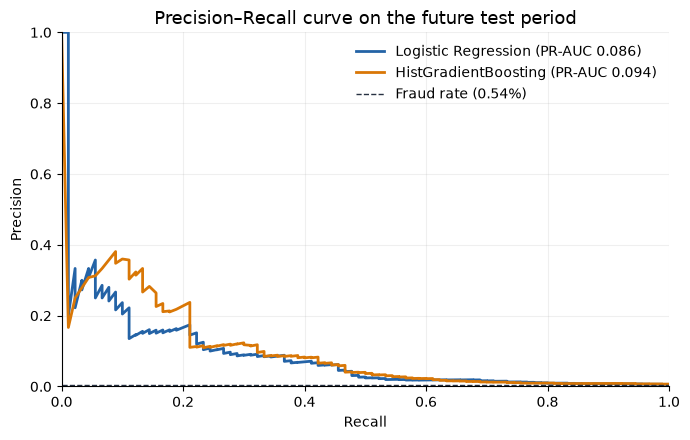

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, probability, color in [
    ("Logistic Regression", test_probabilities["Logistic Regression"], BLUE),
    ("HistGradientBoosting", test_probabilities["HistGradientBoosting"], ORANGE),
]:
    precision, recall, _ = precision_recall_curve(y_test, probability)
    ap = average_precision_score(y_test, probability)
    ax.plot(recall, precision, label=f"{name} (PR-AUC {ap:.3f})", color=color, linewidth=2)
ax.axhline(y_test.mean(), color=CHARCOAL, linestyle="--", linewidth=1, label=f"Fraud rate ({y_test.mean():.2%})")
ax.set(title="Precision–Recall curve on the future test period", xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1))
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ASSET_DIR / "precision_recall_curve.png", dpi=160)
plt.show()

## 9. Threshold Selection

The demonstration objective is **no more than 120 alerts per 1,000 validation transactions**, then the highest recall within that capacity. This is an example operating point, not a universal optimum; production selection would include fraud loss, false-positive cost, and actual daily analyst capacity.

,threshold,precision,recall,alerts_per_1k,alerts
0,0.05,0.005,1.000,1000.000,16627
1,0.10,0.005,1.000,969.808,16125
2,0.15,0.006,0.893,739.279,12292
3,0.20,0.008,0.833,537.800,8942
4,0.25,0.010,0.810,398.569,6627
5,0.30,0.012,0.750,315.330,5243
6,0.35,0.014,0.726,255.007,4240
7,0.40,0.016,0.655,202.442,3366
8,0.45,0.021,0.619,150.358,2500
9,0.50,0.027,0.607,111.686,1857


Selected threshold: 0.50


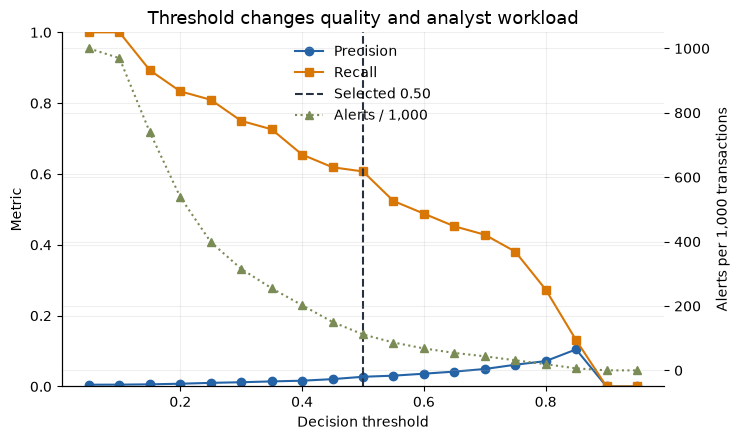

In [8]:
validation_probability = stronger.predict_proba(X_validation)[:, 1]
threshold_rows = []
for threshold in np.arange(0.05, 0.96, 0.05):
    prediction = validation_probability >= threshold
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_validation, prediction, zero_division=0),
        "recall": recall_score(y_validation, prediction, zero_division=0),
        "alerts_per_1k": 1000 * prediction.mean(),
        "alerts": int(prediction.sum()),
    })
threshold_table = pd.DataFrame(threshold_rows)
eligible = threshold_table.loc[threshold_table.alerts_per_1k <= 120]
if len(eligible):
    selected_threshold = float(eligible.sort_values(["recall", "precision"], ascending=False).iloc[0].threshold)
else:
    selected_threshold = float(threshold_table.iloc[(threshold_table.alerts_per_1k - 120).abs().argmin()].threshold)
display(threshold_table.round(3))
print(f"Selected threshold: {selected_threshold:.2f}")

fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
ax1.plot(threshold_table.threshold, threshold_table.precision, marker="o", color=BLUE, label="Precision")
ax1.plot(threshold_table.threshold, threshold_table.recall, marker="s", color=ORANGE, label="Recall")
ax1.axvline(selected_threshold, color=CHARCOAL, linestyle="--", label=f"Selected {selected_threshold:.2f}")
ax1.set(title="Threshold changes quality and analyst workload", xlabel="Decision threshold", ylabel="Metric", ylim=(0, 1))
ax2 = ax1.twinx()
ax2.plot(threshold_table.threshold, threshold_table.alerts_per_1k, color="#7A8B55", linestyle=":", marker="^", label="Alerts / 1,000")
ax2.set_ylabel("Alerts per 1,000 transactions")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], frameon=False, loc="upper center")
fig.tight_layout()
fig.savefig(ASSET_DIR / "threshold_tradeoff.png", dpi=160)
plt.show()

## 10. Explainability

Logistic coefficients show direction after preprocessing. Model-agnostic permutation importance shows which raw features most affect the stronger model's PR-AUC.

,coefficient
categorical__merchant_category_grocery,-0.454010
categorical__merchant_category_digital_goods,-0.379776
categorical__transaction_channel_atm,-0.343596
numeric__std_previous_amount,-0.269089
categorical__customer_segment_standard,-0.245035
categorical__transaction_channel_pos,-0.171419
categorical__merchant_category_fuel,-0.143863
numeric__country_mismatch_indicator,0.181547
numeric__is_international,0.181547
numeric__transactions_previous_1h,0.277125


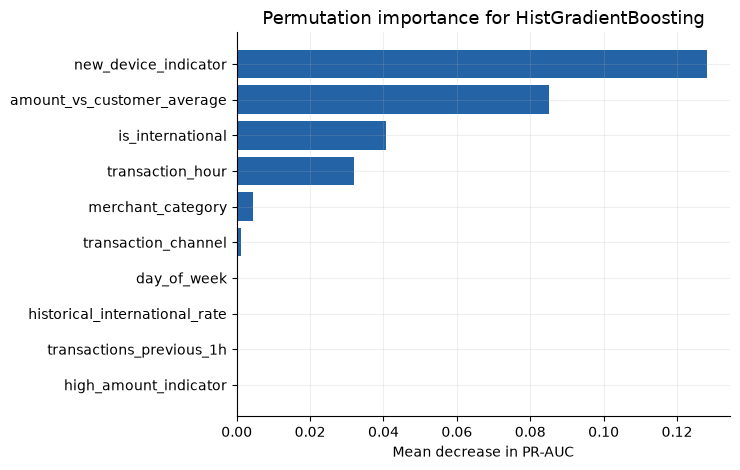

,mean_PR_AUC_decrease
new_device_indicator,0.1280
amount_vs_customer_average,0.0852
is_international,0.0406
transaction_hour,0.0320
merchant_category,0.0045
transaction_channel,0.0013
day_of_week,0.0003
historical_international_rate,0.0000
transactions_previous_1h,0.0000
high_amount_indicator,0.0000


In [9]:
transformed_names = logistic.named_steps["preprocess"].get_feature_names_out()
coefficients = pd.Series(logistic.named_steps["model"].coef_[0], index=transformed_names).sort_values()
display(pd.concat([coefficients.head(7), coefficients.tail(7)]).to_frame("coefficient"))

fraud_sample = test.loc[test.is_fraud.eq(1)]
legitimate_sample = test.loc[test.is_fraud.eq(0)].sample(n=min(4500, (test.is_fraud.eq(0)).sum()), random_state=RANDOM_STATE)
importance_sample = pd.concat([fraud_sample, legitimate_sample]).sample(frac=1, random_state=RANDOM_STATE)
permutation = permutation_importance(
    stronger, importance_sample[model_features], importance_sample.is_fraud,
    scoring="average_precision", n_repeats=3, random_state=RANDOM_STATE, n_jobs=1,
)
importance = pd.Series(permutation.importances_mean, index=model_features).sort_values(ascending=False)
top_importance = importance.head(10).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.barh(top_importance.index, top_importance.values, color=BLUE)
ax.set(title="Permutation importance for HistGradientBoosting", xlabel="Mean decrease in PR-AUC")
fig.tight_layout()
fig.savefig(ASSET_DIR / "feature_importance.png", dpi=160)
plt.show()
display(importance.head(10).to_frame("mean_PR_AUC_decrease").round(4))

## 11. Example Fraud Alerts

The scored test output is the contract between the ML layer and the investigation workflow. It includes model-visible evidence, but the agent never sees the true fraud label.

In [10]:
test_probability = test_probabilities["HistGradientBoosting"]
selected_metrics = classification_metrics(y_test, test_probability, selected_threshold)
scored = test[[
    "transaction_id", "customer_id", "transaction_timestamp", "amount", "merchant_category",
    "merchant_country", "transaction_channel", "transaction_hour", "is_card_present",
    "is_international", "previous_transaction_count", "avg_previous_amount",
    "amount_vs_customer_average", "minutes_since_previous_transaction", "transactions_previous_1h",
    "transactions_previous_24h", "historical_international_rate", "new_device_indicator",
    "new_category_indicator", "unusual_hour_indicator", "is_fraud",
]].copy()
scored = scored.merge(transactions[["transaction_id", "device_id"]], on="transaction_id", how="left")
scored["fraud_probability"] = test_probability
scored["selected_threshold"] = selected_threshold
scored["risk_level"] = np.select(
    [scored.fraud_probability >= selected_threshold,
     scored.fraud_probability >= selected_threshold * 0.60],
    ["HIGH", "MEDIUM"], default="LOW"
)
scored["signal_count"] = (
    (scored.amount_vs_customer_average >= 3).astype(int)
    + scored.is_international.astype(int)
    + scored.new_device_indicator.astype(int)
    + (scored.transactions_previous_1h >= 2).astype(int)
    + scored.unusual_hour_indicator.astype(int)
    + scored.new_category_indicator.astype(int)
)
scored.to_csv(DATA_DIR / "scored_test_transactions.csv", index=False)

alert_columns = ["transaction_id", "fraud_probability", "risk_level", "amount",
                 "amount_vs_customer_average", "is_international", "new_device_indicator",
                 "transactions_previous_1h", "unusual_hour_indicator"]
display(scored.loc[scored.risk_level.eq("HIGH")].sort_values("fraud_probability", ascending=False)[alert_columns].head(5).round(3))

,transaction_id,fraud_probability,risk_level,amount,amount_vs_customer_average,is_international,new_device_indicator,transactions_previous_1h,unusual_hour_indicator
13999,TX_001151,0.901,HIGH,315.44,2.831,1,1,0,0
11421,TX_074381,0.901,HIGH,478.93,3.435,1,1,0,0
680,TX_035998,0.901,HIGH,473.16,4.314,1,1,0,0
12923,TX_099247,0.901,HIGH,312.92,4.068,1,1,0,0
6707,TX_064140,0.901,HIGH,313.02,3.265,1,1,0,0


## 12. Key Takeaways

- Historical features are computed only from earlier transactions.
- PR-AUC is emphasized because fraud is rare.
- The stronger model ranks future cases; the threshold converts ranking into analyst workload.
- Model scores create alerts—not final fraud decisions.

In [11]:
metadata = {
    "dataset": {
        "customers": int(len(customers)), "transactions": int(len(transactions)),
        "fraud_cases": int(transactions.is_fraud.sum()), "fraud_rate": float(transactions.is_fraud.mean()),
        "start": str(transactions.transaction_timestamp.min()), "end": str(transactions.transaction_timestamp.max()),
    },
    "splits": {
        name: {"rows": int(row.rows), "start": str(row.start), "end": str(row.end), "fraud_rate": float(row.fraud_rate)}
        for name, row in split_summary.iterrows()
    },
    "metrics_at_0_50": {
        name: {k: (int(v) if k in {"tn", "fp", "fn", "tp"} else float(v)) for k, v in values.items()}
        for name, values in {n: classification_metrics(y_test, p) for n, p in test_probabilities.items()}.items()
    },
    "selected_threshold": selected_threshold,
    "selected_threshold_test_metrics": {k: (int(v) if k in {"tn", "fp", "fn", "tp"} else float(v)) for k, v in selected_metrics.items()},
    "test_alerts": int((test_probability >= selected_threshold).sum()),
    "alerts_per_1000": float(1000 * (test_probability >= selected_threshold).mean()),
    "top_permutation_features": {k: float(v) for k, v in importance.head(10).items()},
    "top_positive_logistic_coefficients": {k: float(v) for k, v in coefficients.tail(7).sort_values(ascending=False).items()},
    "top_negative_logistic_coefficients": {k: float(v) for k, v in coefficients.head(7).items()},
}
(DATA_DIR / "model_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print(json.dumps({
    "selected_threshold": selected_threshold,
    "test_precision": selected_metrics["precision"],
    "test_recall": selected_metrics["recall"],
    "test_alerts": metadata["test_alerts"],
}, indent=2))

{
  "selected_threshold": 0.5,
  "test_precision": 0.02897693672383205,
  "test_recall": 0.5444444444444444,
  "test_alerts": 1691
}
